<a href="https://colab.research.google.com/github/vanshkothare/Machine-learning-5th-SEM-project/blob/main/PRACTICAL_NO_10_DL_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x_train)
    print(f"{e + 1}/{epochs}, error={error}")
    errorlist.append(error)

1/50, error=0.06439410564054218
2/50, error=0.03274281757581782
3/50, error=0.023773863219535445
4/50, error=0.02000450258342078
5/50, error=0.017878300076810266
6/50, error=0.016434471509799334
7/50, error=0.015349470890539636
8/50, error=0.014482367091227227
9/50, error=0.013759946487616468
10/50, error=0.013139809142450653
11/50, error=0.012595756496564827
12/50, error=0.012110700903435209
13/50, error=0.01167282331402958
14/50, error=0.011273528300274931
15/50, error=0.010906374805939482
16/50, error=0.01056646711233932
17/50, error=0.010250043827507502
18/50, error=0.009954145418554636
19/50, error=0.009676347588008744
20/50, error=0.009414598689907492
21/50, error=0.00916714827158956
22/50, error=0.008932508452623665
23/50, error=0.008709414654903682
24/50, error=0.008496786246003096
25/50, error=0.008293696609380374
26/50, error=0.008099357074805734
27/50, error=0.007913105758254619
28/50, error=0.0077343785310519195
29/50, error=0.00756266044353834
30/50, error=0.00739745506706

In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
!pip install simple-colors

In [ ]:
import simple_colors

In [ ]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '	true:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} 	true: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 6 	true: 5
pred: 9 	true: 9
pred: 0 	true: 0
pred: 6 	true: 6
pred: 9 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.95
Correct: 19


In [ ]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

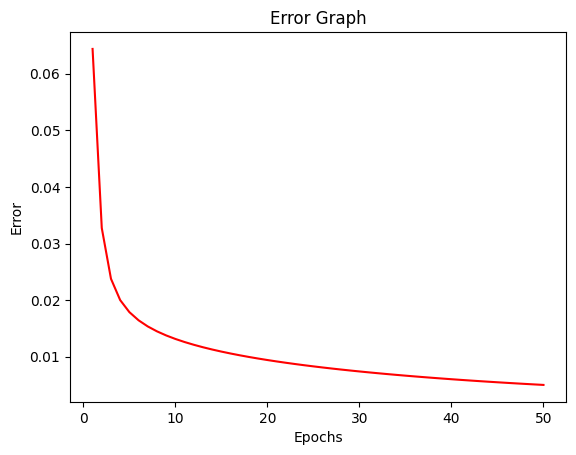

In [ ]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()